<a href="https://colab.research.google.com/github/ChiragShetye/Kaggle-House-Price-Prediction/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12, 10)
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error as mse

In [184]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [185]:
import pandas as pd
from sklearn.impute import SimpleImputer as Imputer
from random import choices
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.base import BaseEstimator

In [186]:
!gdown 1F9aD344ifJiKzRDlR4ZX0e4plDuP9-b9

Downloading...
From: https://drive.google.com/uc?id=1F9aD344ifJiKzRDlR4ZX0e4plDuP9-b9
To: /content/kaggle_houseprices_modified.csv
100% 459k/459k [00:00<00:00, 14.7MB/s]


In [187]:
ds = pd.read_csv('/content/kaggle_houseprices_modified.csv')

In [188]:
ds.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,198075.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,199650.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,212325.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,237500.0


In [189]:
ds.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [190]:
ds[ds.columns[80:]].head()

,SalePrice
0,198075.0
1,199650.0
2,212325.0
3,140000.0
4,237500.0


In [191]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Preprocessing


In [192]:
todrop = ['Id']
categorical = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
               'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'RoofStyle', 'RoofMatl', 'HouseStyle',
               'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating', 'CentralAir',
               'Electrical', 'GarageType', 'PavedDrive', 'Fence', 'MiscFeature', 'MoSold', 'SaleType', 'SaleCondition']
continuous = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1',
              'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'MasVnrArea',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
              'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
              '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'YrSold', 'SalePrice']
cat_to_con = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
              'HeatingQC', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond',
              'PoolQC', ]

In [193]:
# run the imputation when not making pipeline

ds['LotFrontage'] = ds['LotFrontage'].fillna(ds['LotFrontage'].median())
ds['MasVnrArea']  = ds['MasVnrArea'].fillna(ds['MasVnrArea'].median())
ds['GarageYrBlt'] = ds['GarageYrBlt'].fillna(ds['GarageYrBlt'].mean())
print(ds[continuous].isna().sum().sum())

0


In [194]:
  def pre_processing(ds, todrop, categorical, cat_to_con):
    #dropping
    ds = ds.drop(columns=todrop)

    #categorical
    logical_nans = ['Alley', 'Fence', 'MiscFeature', 'MasVnrType', 'GarageType', ]
    for col in logical_nans:
        ds[col] = ds[col].fillna('NA')
    ds['Electrical'] = ds['Electrical'].fillna(ds['Electrical'].value_counts().index[0])  # mode
    print("no. of nans in categorical cols:", ds[categorical].isna().sum().sum())


    #cat_to_con
    ds['FireplaceQu'] = ds['FireplaceQu'].fillna('NA')
    logical_nans = ['FireplaceQu', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                    'BsmtFinType2', 'GarageFinish', 'GarageQual', 'GarageCond']
    for col in logical_nans:
        ds[col] = ds[col].fillna('NA')

    ds.drop(columns = ['PoolQC'], inplace=True)
    cat_to_con.remove('PoolQC')
    print("no. of nans in cat_to_con cols:",ds[cat_to_con].isna().sum().sum())

    #target_encoding
    target = 'SalePrice'
    for col in categorical:
        ds[col] = ds.groupby([col])[target].transform('mean')

    #label encoding
    grp1 = ['GarageQual', 'GarageCond', 'FireplaceQu', 'KitchenQual', 'HeatingQC', 'BsmtCond', 'BsmtQual', 'ExterCond', 'ExterQual']
    for col in grp1:
        ds[col] = ds[col].map({'TA': 3, 'Fa': 2, 'NA': 0, 'Gd': 4, 'Po': 1, 'Ex': 5})

    for col in ['BsmtFinType1', 'BsmtFinType2']:
        ds[col] = ds[col].map({'GLQ':6, 'ALQ':5, 'Unf':1, 'Rec':3, 'BLQ':4, 'NA':0, 'LwQ':2})

    ds['BsmtExposure'] = ds['BsmtExposure'].map({'No':1, 'Gd':4, 'Mn':2, 'Av':3, 'NA':0})
    ds['Functional'] = ds['Functional'].map({'Typ':7, 'Min1':6, 'Maj1':3, 'Min2':5, 'Mod':4, 'Maj2':2, 'Sev':1, 'Sal':0})
    ds['GarageFinish'] = ds['GarageFinish'].map({'RFn':2, 'Unf':1, 'Fin':3, 'NA':0})

    print("total nans in the dataframe:", ds.isna().sum().sum())

    return ds

In [195]:
ds = pre_processing(ds, todrop, categorical, cat_to_con)

no. of nans in categorical cols: 0
no. of nans in cat_to_con cols: 0
total nans in the dataframe: 0


In [196]:
  ds

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,252692.601839,204994.032276,65.0,8450,194047.191231,196590.593755,176882.391676,193292.650229,193813.919842,190814.936930,...,0,0,201832.730831,195275.313691,0,184007.670192,2008,175316.452684,177454.242947,198075.0
1,207766.905970,204994.032276,80.0,9600,194047.191231,196590.593755,176882.391676,193292.650229,193813.919842,178829.893617,...,0,0,201832.730831,195275.313691,0,181414.566176,2007,175316.452684,177454.242947,199650.0
2,252692.601839,204994.032276,68.0,11250,194047.191231,196590.593755,219936.183574,193292.650229,193813.919842,190814.936930,...,0,0,201832.730831,195275.313691,0,216298.142857,2008,175316.452684,177454.242947,212325.0
3,174123.741667,204994.032276,60.0,9550,194047.191231,196590.593755,219936.183574,193292.650229,193813.919842,193082.861217,...,0,0,201832.730831,195275.313691,0,184007.670192,2006,175316.452684,146527.787129,140000.0
4,252692.601839,204994.032276,84.0,14260,194047.191231,196590.593755,219936.183574,193292.650229,193813.919842,178829.893617,...,0,0,201832.730831,195275.313691,0,197798.869492,2008,175316.452684,177454.242947,237500.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,252692.601839,204994.032276,62.0,7917,194047.191231,196590.593755,176882.391676,193292.650229,193813.919842,190814.936930,...,0,0,201832.730831,195275.313691,0,200841.786885,2007,175316.452684,177454.242947,166250.0
1456,207766.905970,204994.032276,85.0,13175,194047.191231,196590.593755,176882.391676,193292.650229,193813.919842,190814.936930,...,0,0,155835.051592,195275.313691,0,184007.670192,2010,175316.452684,177454.242947,231000.0
1457,174123.741667,204994.032276,66.0,9042,194047.191231,196590.593755,176882.391676,193292.650229,193813.919842,190814.936930,...,0,0,182889.576271,154880.979592,2500,181414.566176,2010,175316.452684,177454.242947,253175.0
1458,207766.905970,204994.032276,68.0,9717,194047.191231,196590.593755,176882.391676,193292.650229,193813.919842,190814.936930,...,0,0,201832.730831,195275.313691,0,181148.804255,2010,175316.452684,177454.242947,156337.5


In [197]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 79 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   float64
 1   MSZoning       1460 non-null   float64
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   float64
 5   Alley          1460 non-null   float64
 6   LotShape       1460 non-null   float64
 7   LandContour    1460 non-null   float64
 8   Utilities      1460 non-null   float64
 9   LotConfig      1460 non-null   float64
 10  LandSlope      1460 non-null   float64
 11  Neighborhood   1460 non-null   float64
 12  Condition1     1460 non-null   float64
 13  Condition2     1460 non-null   float64
 14  BldgType       1460 non-null   float64
 15  HouseStyle     1460 non-null   float64
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [198]:
ds.describe()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,193784.766473,193784.766473,69.863699,10516.828082,193784.766473,193784.766473,193784.766473,193784.766473,193784.766473,193784.766473,...,15.060959,2.758904,193784.766473,193784.766473,43.489041,193784.766473,2007.815753,193784.766473,193784.766473,193784.766473
std,45437.758786,31822.387064,22.027677,9981.264932,4086.581515,13232.392569,23002.475340,15534.371834,1113.948694,11337.630486,...,55.757415,40.177307,17324.597143,8337.501820,496.123024,10723.829657,1.328095,64765.201359,64142.443826,103896.507717
min,91550.000000,73276.870000,21.000000,1300.000000,130190.500000,124300.488000,176882.391676,147545.992063,151250.000000,178829.893617,...,0.000000,0.000000,146015.000000,94000.000000,0.000000,181148.804255,2006.000000,91251.666667,78225.000000,20940.000000
25%,150141.173611,204994.032276,60.000000,7553.500000,194047.191231,196590.593755,176882.391676,193292.650229,193813.919842,190814.936930,...,0.000000,0.000000,201832.730831,195275.313691,0.000000,184007.670192,2007.000000,175316.452684,177454.242947,139060.625000
50%,207766.905970,204994.032276,69.000000,9478.500000,194047.191231,196590.593755,176882.391676,193292.650229,193813.919842,190814.936930,...,0.000000,0.000000,201832.730831,195275.313691,0.000000,192362.900943,2008.000000,175316.452684,177454.242947,170500.000000
75%,218035.000000,204994.032276,79.000000,11601.500000,194047.191231,196590.593755,219936.183574,193292.650229,193813.919842,190814.936930,...,0.000000,0.000000,201832.730831,195275.313691,0.000000,203307.012393,2009.000000,175316.452684,177454.242947,223625.000000
max,252692.601839,248375.383077,313.000000,215245.000000,194047.191231,196590.593755,255879.595122,259341.542000,193813.919842,235935.562766,...,480.000000,738.000000,201832.730831,250000.000000,15500.000000,216298.142857,2010.000000,406700.434426,400976.648000,917485.500000


In [199]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler


scaler = StandardScaler()

ds_scaled = scaler.fit_transform(ds)

In [200]:

ds_scaled

array([[ 1.29689538,  0.35236535, -0.22087509, ..., -0.28525568,
        -0.25468501,  0.04130749],
       [ 0.30782615,  0.35236535,  0.46031974, ..., -0.28525568,
        -0.25468501,  0.056472  ],
       [ 1.29689538,  0.35236535, -0.08463612, ..., -0.28525568,
        -0.25468501,  0.1785102 ],
       ...,
       [-0.43285061,  0.35236535, -0.1754621 , ..., -0.28525568,
        -0.25468501,  0.57182464],
       [ 0.30782615,  0.35236535, -0.08463612, ..., -0.28525568,
        -0.25468501, -0.36055204],
       [ 0.30782615,  0.35236535,  0.23325479, ..., -0.28525568,
        -0.25468501, -0.30362495]])

Training a Linear Regression Model

In [201]:
X = ds_scaled[:, :-1]

y = ds['SalePrice'].values
X.shape, y.shape

((1460, 78), (1460,))

In [202]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape , y_train.shape, y_test.shape

((1168, 78), (292, 78), (1168,), (292,))

In [203]:
# Linear regression [implementation]
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()
model1.fit(X_train, y_train) # training the model

LinearRegression()

In [204]:
model1.coef_

array([ -508.53629767,  -127.28276626,  -324.10764592,  1025.87967502,
        1453.13554551,  2614.50547095,   -86.16156746,  3543.57111934,
        2379.04731894,  3770.49589801,   642.38453364, 19749.26882524,
        3324.18626316,  -672.40075502,   959.95734815, -2615.96488049,
       11431.85128765,  5826.50264677, -6310.46664344, -4188.63642234,
        3904.42570489,   -31.41351634,  -457.08543729,  3056.0996032 ,
       -1061.68151313,  2709.60338213,  4462.82832181,   985.73314426,
       -1111.19547545,  6933.89456559, -5782.74224132,  2893.93145117,
        2763.04274327,  2556.20501647,  -978.39464797,  1436.31628673,
        -542.39557507,  2639.40048326,   248.8251998 ,  -179.15435951,
        1430.08575274, -2319.16335486,  8744.35187514,  1839.0377576 ,
        -800.18926615,  7886.77170603,  3540.49462812,  -135.1167069 ,
        1693.42155259,  2765.91687268, -1065.02878975, -8649.46532928,
        6861.91093447, 11332.33761448,  3153.44074852,  3274.70614938,
      

In [205]:
model1.intercept_

192997.08038911724

Predictions from our Linear Regression Model

In [206]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Train the model (Linear Regression example)
model = LinearRegression()
model.fit(X_train, y_train)

# Predict for training and testing sets
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluate the model performance on both training and testing data
# Calculate metrics for training data
mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

# Calculate metrics for test data
mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print evaluation metrics
print("Training Data Metrics:")
print(f"MSE: {mse_train:.4f}, MAE: {mae_train:.4f}, R²: {r2_train:.4f}")
print("\nTest Data Metrics:")
print(f"MSE: {mse_test:.4f}, MAE: {mae_test:.4f}, R²: {r2_test:.4f}")

Training Data Metrics:
MSE: 1446595241.2733, MAE: 23269.3293, R²: 0.8562

Test Data Metrics:
MSE: 2028598486.7990, MAE: 24417.3631, R²: 0.8520


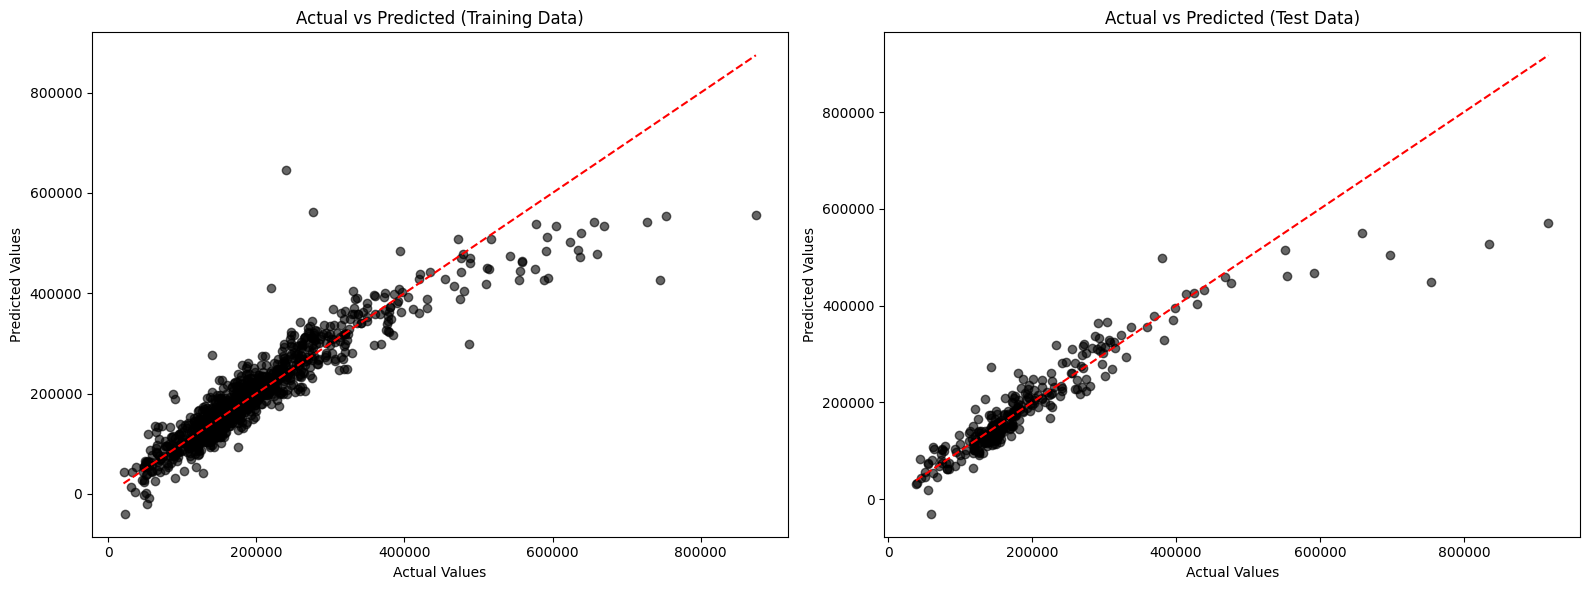

In [207]:
# Visualize Actual vs Predicted.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Training data plot
axes[0].scatter(y_train, y_pred_train, color='black', alpha=0.6)
axes[0].plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='red', linestyle='--')  # Perfect prediction line
axes[0].set_title('Actual vs Predicted (Training Data)')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')

# Test data plot
axes[1].scatter(y_test, y_pred_test, color='black', alpha=0.6)
axes[1].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Perfect prediction line
axes[1].set_title('Actual vs Predicted (Test Data)')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

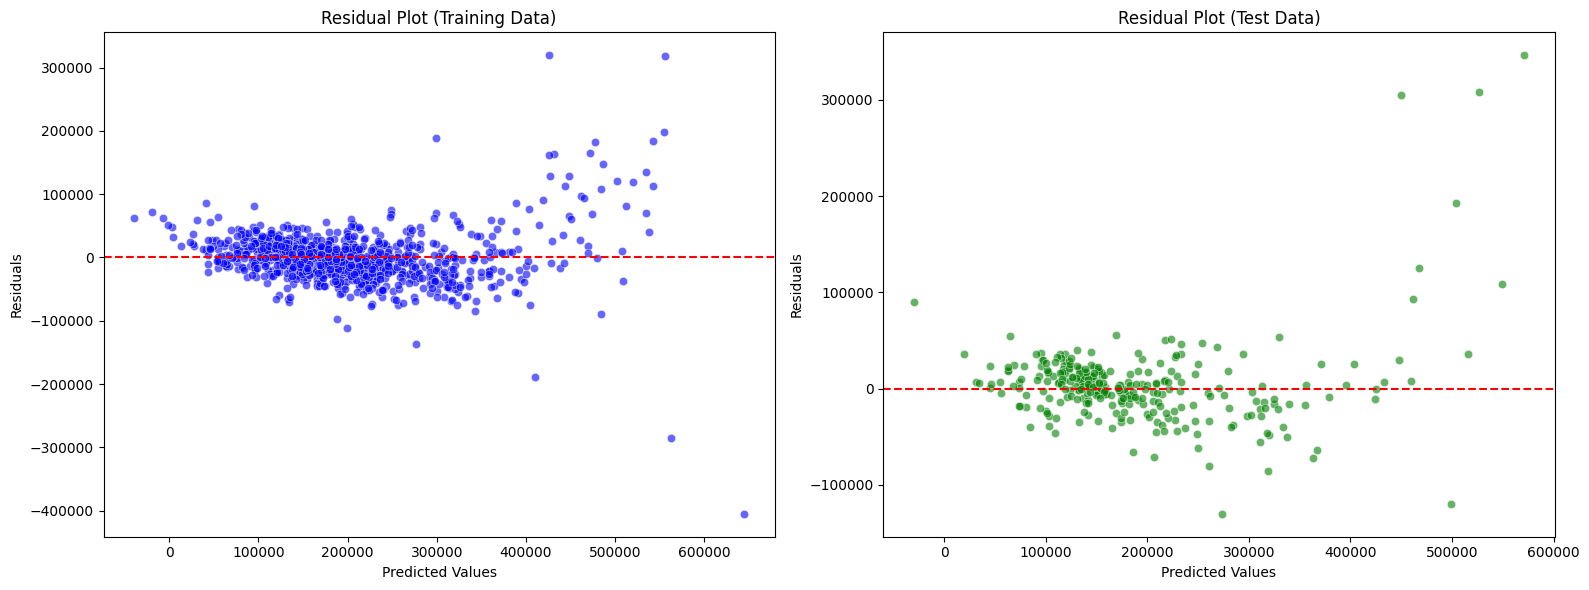

In [208]:
import seaborn as sns

# Residuals Plot.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training residuals plot
residuals_train = y_train - y_pred_train
sns.scatterplot(x=y_pred_train, y=residuals_train, color='blue', alpha=0.6, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residual Plot (Training Data)')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')

# Test residuals plot
residuals_test = y_test - y_pred_test
sns.scatterplot(x=y_pred_test, y=residuals_test, color='green', alpha=0.6, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residual Plot (Test Data)')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

Polynomial Regression:


In [209]:
from sklearn.preprocessing import PolynomialFeatures
# Create Polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train the Polynomial Regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Predict for training and testing sets
y_pred_train_poly = poly_model.predict(X_train_poly)
y_pred_test_poly = poly_model.predict(X_test_poly)

# Evaluate the Polynomial model performance
mse_train_poly = mean_squared_error(y_train, y_pred_train_poly)
mae_train_poly = mean_absolute_error(y_train, y_pred_train_poly)
r2_train_poly = r2_score(y_train, y_pred_train_poly)

mse_test_poly = mean_squared_error(y_test, y_pred_test_poly)
mae_test_poly = mean_absolute_error(y_test, y_pred_test_poly)
r2_test_poly = r2_score(y_test, y_pred_test_poly)

# Print evaluation metrics
print("Polynomial Regression - Training Data Metrics:")
print(f"MSE: {mse_train_poly:.4f}, MAE: {mae_train_poly:.4f}, R²: {r2_train_poly:.4f}")
print("\nPolynomial Regression - Test Data Metrics:")
print(f"MSE: {mse_test_poly:.4f}, MAE: {mae_test_poly:.4f}, R²: {r2_test_poly:.4f}")

Polynomial Regression - Training Data Metrics:
MSE: 0.0000, MAE: 0.0000, R²: 1.0000

Polynomial Regression - Test Data Metrics:
MSE: 4198431641.3503, MAE: 42743.7889, R²: 0.6936


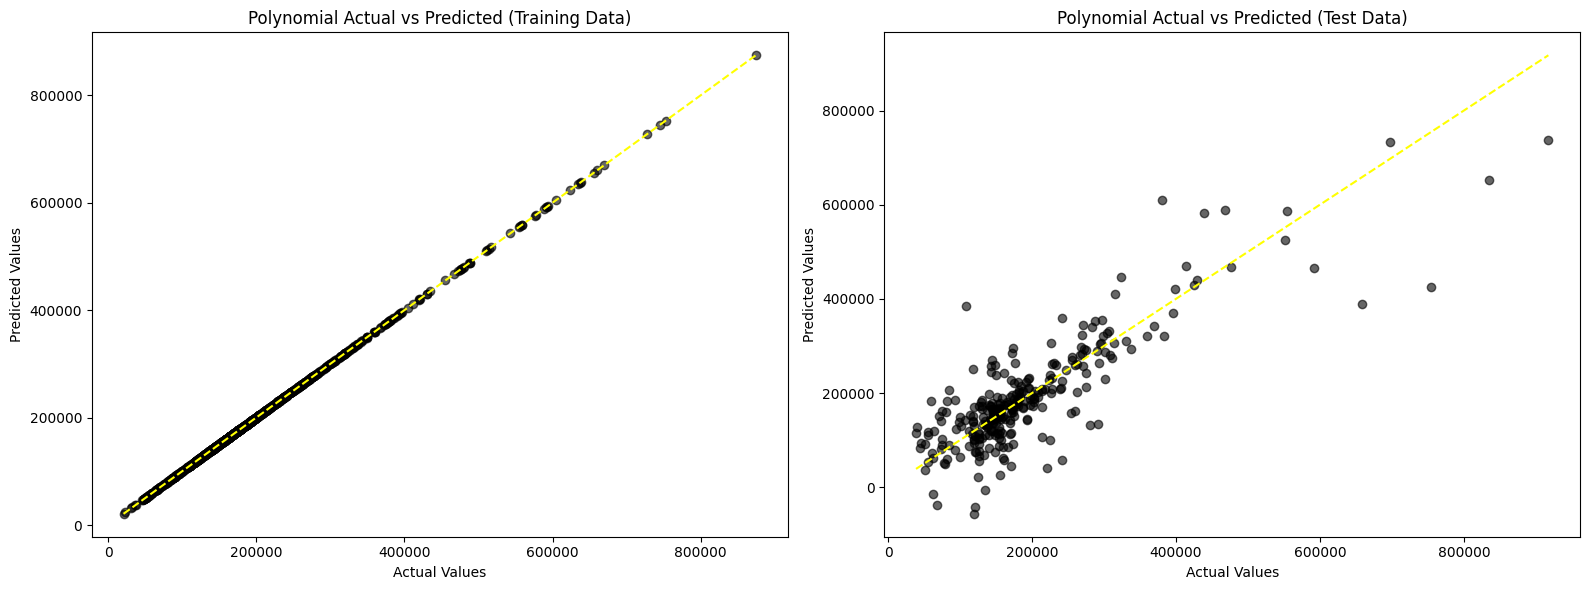

In [210]:
# Visualize Actual vs Predicted (Side by Side)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Training data plot (Polynomial Regression)
axes[0].scatter(y_train, y_pred_train_poly, color='black', alpha=0.6)
axes[0].plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], color='yellow', linestyle='--')  # Perfect prediction line
axes[0].set_title('Polynomial Actual vs Predicted (Training Data)')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')

# Test data plot (Polynomial Regression)
axes[1].scatter(y_test, y_pred_test_poly, color='black', alpha=0.6)
axes[1].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='yellow', linestyle='--')  # Perfect prediction line
axes[1].set_title('Polynomial Actual vs Predicted (Test Data)')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

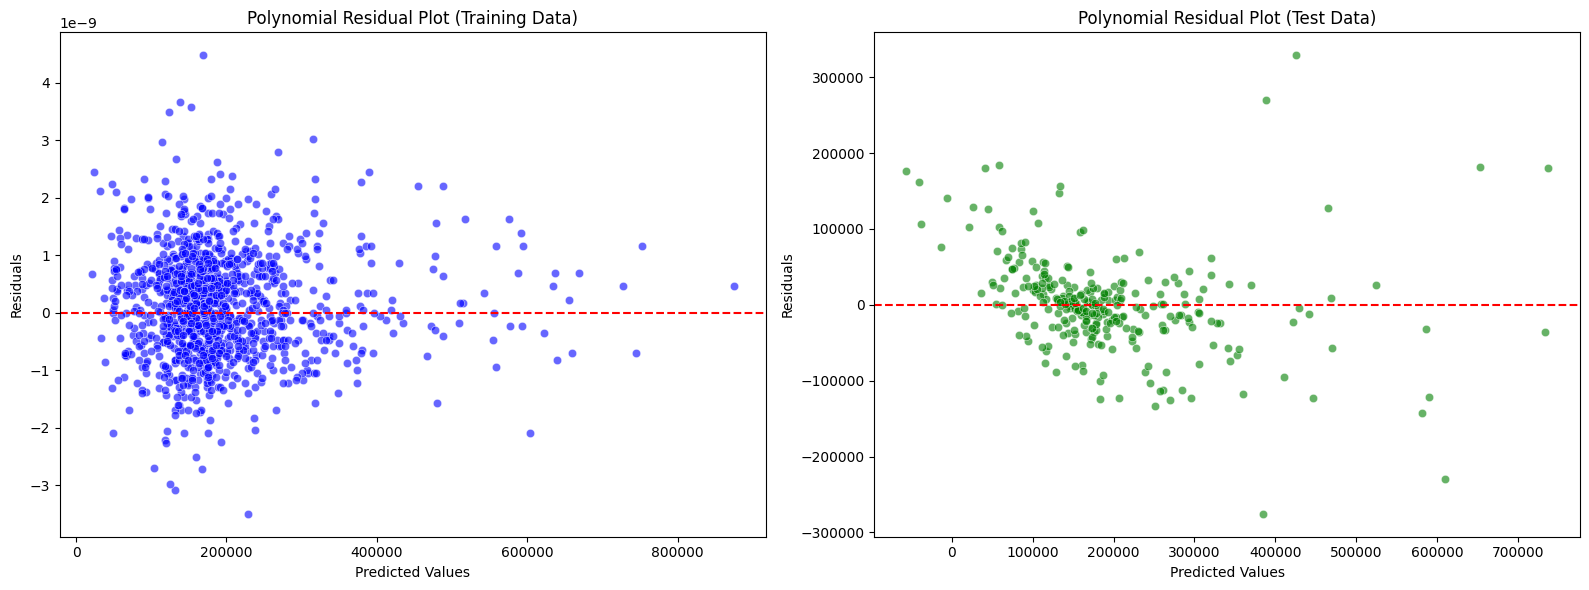

In [211]:
# Residuals Plot (Side by Side)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training residuals plot (Polynomial Regression)
residuals_train_poly = y_train - y_pred_train_poly
sns.scatterplot(x=y_pred_train_poly, y=residuals_train_poly, color='blue', alpha=0.6, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Polynomial Residual Plot (Training Data)')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')

# Test residuals plot (Polynomial Regression)
residuals_test_poly = y_test - y_pred_test_poly
sns.scatterplot(x=y_pred_test_poly, y=residuals_test_poly, color='green', alpha=0.6, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Polynomial Residual Plot (Test Data)')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

Regularization


In [212]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape , y_train.shape, y_test.shape

((1168, 78), (292, 78), (1168,), (292,))

In [213]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures

degree = 2
poly = PolynomialFeatures(degree=degree)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)



In [214]:
# standadize the polynomial features
scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)


In [215]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_poly_scaled , y_train)
output = model.predict(X_test_poly_scaled)


In [216]:
from sklearn.metrics import mean_squared_error
print('MSE for test:', mean_squared_error(y_test, output))
output = model.predict(X_train_poly_scaled)
print('MSE for train:', mean_squared_error(y_train, output))

print("R^2 for train:",model.score(X_train_poly_scaled,y_train))
print('R^2 for test:',model.score(X_test_poly_scaled,y_test))

MSE for test: 4439875185.484336
MSE for train: 1.366446622230564e-19
R^2 for train: 1.0
R^2 for test: 0.6760207867280483


In [217]:
from sklearn.linear_model import Lasso, Ridge
lasso_model = Lasso(alpha=2) # Alpha is the regularization strength
# Fit the models to the training data
lasso_model.fit(X_train_poly_scaled, y_train)
lasso_predictions = lasso_model.predict(X_test_poly_scaled)
print("R^2 for train:",lasso_model.score(X_train_poly_scaled,y_train))
print('R^2 for test:',lasso_model.score(X_test_poly_scaled,y_test))

R^2 for train: 0.9999594622058563
R^2 for test: 0.6888939163255966


In [218]:
lasso_model.coef_.round(2)[:50]

array([ 0.000000e+00,  2.782260e+04,  9.210550e+03,  8.694090e+03,
        9.063440e+03,  8.775000e+01,  3.779140e+03, -6.798000e+02,
        8.635020e+03,  0.000000e+00,  4.549080e+03, -4.242470e+03,
        2.489818e+04,  0.000000e+00,  5.003920e+03,  1.833860e+03,
       -7.235320e+03,  1.374420e+04,  5.598920e+03,  1.175840e+03,
        7.352310e+03,  4.511620e+03,  2.246720e+03,  6.381300e+02,
       -0.000000e+00,  9.161800e+02, -0.000000e+00,  8.890980e+03,
        4.000000e-01,  7.661300e+02,  1.362240e+03,  6.381200e+02,
        1.194980e+03,  9.847700e+02,  6.217360e+03, -6.896000e+01,
       -0.000000e+00,  3.306110e+03,  3.845850e+03,  8.068500e+02,
        0.000000e+00, -4.063140e+03, -1.348650e+03,  1.196124e+04,
        1.044720e+04,  3.317430e+03,  2.811510e+03,  2.226600e+03,
       -8.877400e+02,  1.279040e+03])

In [219]:
ridge_model = Ridge(alpha=2000) # Alpha is the regularization strength
ridge_model.fit(X_train_poly_scaled, y_train)
ridge_predictions = ridge_model.predict(X_test_poly_scaled)
print("R^2 for train:",ridge_model.score(X_train_poly_scaled,y_train))
print('R^2 for test:',ridge_model.score(X_test_poly_scaled,y_test))

R^2 for train: 0.962687868111341
R^2 for test: 0.8715837480278334


In [220]:
ridge_model.coef_.round(2)[:50]

array([   0.  , 1398.78, 1392.83, 1345.04,  979.97,   53.03,  385.64,
        696.88,  798.16,   18.56,  548.47,  -31.91, 2031.43,  791.77,
         51.93,  672.02,  720.56, 2893.03,  914.89, 1128.74, 1477.74,
        644.7 ,   77.24,  754.76,  449.52,  797.83,  858.86, 1707.55,
        102.2 , 1222.6 , 1643.91,  585.03, 1097.37, 1378.3 , 1878.1 ,
         35.79,   37.78,  604.18, 2582.03,  122.2 , 1136.06,  455.42,
        410.2 , 3097.93, 1390.  , -272.42, 3424.37, 1195.5 , -215.31,
       2487.3 ])

In [221]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ElasticNet Model
elastic_model = ElasticNet(alpha=2000, l1_ratio=0.5, max_iter=10000, random_state=42)  # Adjust alpha and l1_ratio as needed
elastic_model.fit(X_train_poly_scaled, y_train)

# Predictions
elastic_predictions_train = elastic_model.predict(X_train_poly_scaled)
elastic_predictions_test = elastic_model.predict(X_test_poly_scaled)

# R^2 Scores
print("ElasticNet Model Performance:")
print(f"R² for train: {elastic_model.score(X_train_poly_scaled, y_train):.4f}")
print(f"R² for test: {elastic_model.score(X_test_poly_scaled, y_test):.4f}")

# Evaluate Performance
mse_train_elastic = mean_squared_error(y_train, elastic_predictions_train)
mse_test_elastic = mean_squared_error(y_test, elastic_predictions_test)
mae_train_elastic = mean_absolute_error(y_train, elastic_predictions_train)
mae_test_elastic = mean_absolute_error(y_test, elastic_predictions_test)

print(f"MSE (Train): {mse_train_elastic:.4f}, MSE (Test): {mse_test_elastic:.4f}")
print(f"MAE (Train): {mae_train_elastic:.4f}, MAE (Test): {mae_test_elastic:.4f}")

ElasticNet Model Performance:
R² for train: 0.1031
R² for test: 0.0969
MSE (Train): 9020890442.1248, MSE (Test): 12375703068.3758
MAE (Train): 64080.8022, MAE (Test): 73146.8762


Decision Tree and Random Forest Models:

In [222]:
X.shape, y.shape

((1460, 78), (1460,))

In [223]:
import warnings
# Ignore all warnings
warnings.filterwarnings("ignore")

In [224]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the models
decision_tree = DecisionTreeRegressor(random_state=42)
random_forest = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the models on the non-scaled training data
decision_tree.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

# Predict using both models
y_pred_tree = decision_tree.predict(X_test)
y_pred_forest = random_forest.predict(X_test)

# Calculate Mean Squared Error (MSE) and R² for both models
mse_tree = mean_squared_error(y_test, y_pred_tree)
mse_forest = mean_squared_error(y_test, y_pred_forest)

r2_tree = r2_score(y_test, y_pred_tree)
r2_forest = r2_score(y_test, y_pred_forest)

print(f"Decision Tree - MSE: {mse_tree:.2f}, R²: {r2_tree:.2f}")
print(f"Random Forest - MSE: {mse_forest:.2f}, R²: {r2_forest:.2f}")

Decision Tree - MSE: 3183012964.95, R²: 0.75
Random Forest - MSE: 1333411556.13, R²: 0.90


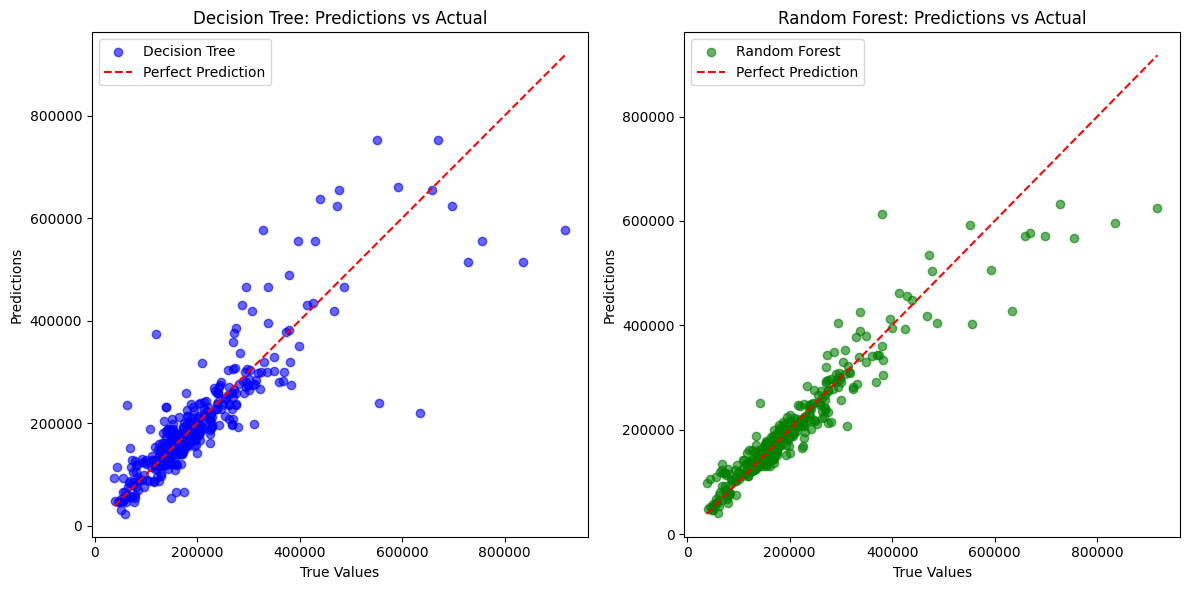

In [225]:
# Plot predictions vs true values for both models
plt.figure(figsize=(12, 6))

# Decision Tree
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_tree, color='blue', alpha=0.6, label='Decision Tree')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Decision Tree: Predictions vs Actual')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.legend()

# Random Forest
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_forest, color='green', alpha=0.6, label='Random Forest')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Random Forest: Predictions vs Actual')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.legend()

plt.tight_layout()
plt.show()

Compare the Models

In [226]:
# Compare the models based on error metrics
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest'],
    'MSE': [mse_tree, mse_forest],
    'R²': [r2_tree, r2_forest]
})

print("\nModel Comparison:")
print(comparison)


Model Comparison:
           Model           MSE        R²
0  Decision Tree  3.183013e+09  0.750516
1  Random Forest  1.333412e+09  0.895487


Boosting

In [227]:
X = ds_scaled[:, :-1]

y = ds['SalePrice'].values

In [228]:
# Initialize KFold cross-validation with 5 splits
kf = KFold(n_splits=5)

# Empty arrays to store true and predicted values for later evaluation
y_true, y_pred = np.array([]), np.array([])

# Loop over each split in the cross-validation
for train_index, test_index in kf.split(X):

    # Split the data into training and testing sets based on the current fold
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    # Initialize a Gradient Boosting Regressor model with a fixed random seed for reproducibility
    baseline_estimator = GradientBoostingRegressor(random_state=0)

    # Fit the model to the training data
    baseline_estimator.fit(X_train, y_train)

    # Append the true values (y_test) and predicted values (from model's predictions on X_test)
    # to the previously initialized arrays to collect results from all folds
    y_true = np.append(y_true, y_test)
    y_pred = np.append(y_pred, baseline_estimator.predict(X_test))

rmse = mse(y_true, y_pred)**0.5
print(f"Root Mean Squared Error (RMSE): {rmse}")

mape_value = mape(y_true, y_pred)
print(f"Mean Absolute Percentage Error (MAPE): {mape_value}")

Root Mean Squared Error (RMSE): 31277.140430213938
Mean Absolute Percentage Error (MAPE): 0.10184115406028563


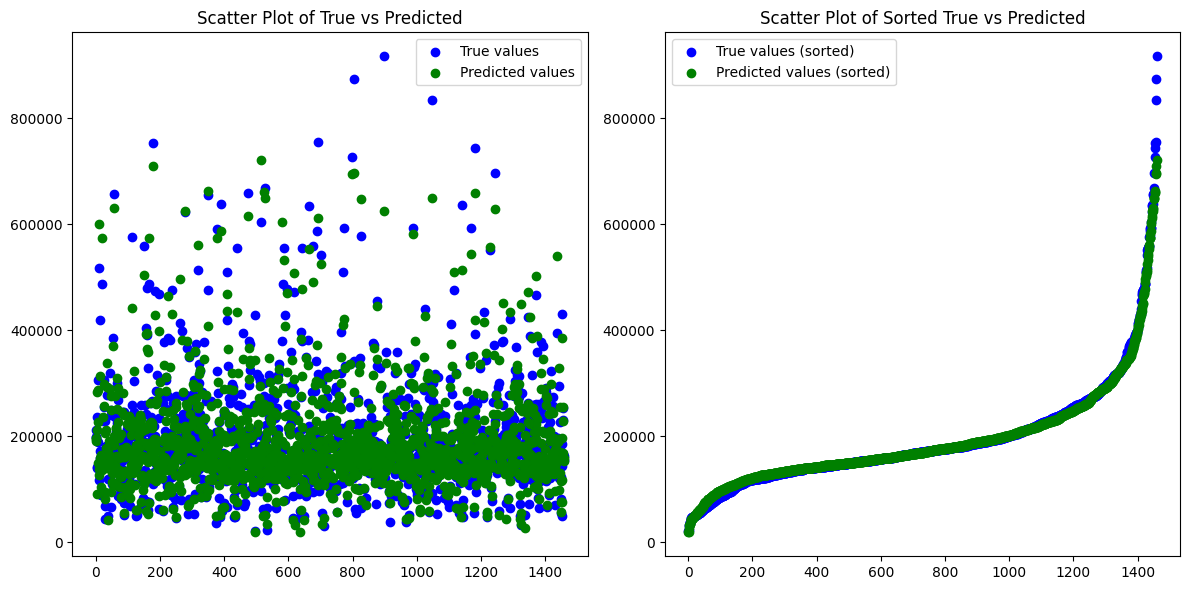

In [229]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# First plot: Scatter plot of true values (y_true) & predicted values (y_pred)
axes[0].scatter(range(len(y_true)), y_true, label='True values', color='blue')
axes[0].scatter(range(len(y_true)), y_pred, label='Predicted values', color='green')
axes[0].set_title('Scatter Plot of True vs Predicted')
axes[0].legend()

# Second plot: Scatter plot of true values (y_true) & predicted values (y_pred) in sorted form
axes[1].scatter(range(len(y_true)), sorted(y_true), label='True values (sorted)', color='blue')
axes[1].scatter(range(len(y_true)), sorted(y_pred), label='Predicted values (sorted)', color='green')
axes[1].set_title('Scatter Plot of Sorted True vs Predicted')
axes[1].legend()

# Adjust the layout to make it look better
plt.tight_layout()

# Display the plots
plt.show()

**Conclusion:**
In conclusion, Random Forest still provides the most accurate predictions with the best generalization, while Boosting offers a solid alternative with good error metrics. Both models outperform Decision Tree and Polynomial Regression in terms of predictive accuracy.

Principal Component Analysis.

In [230]:
from sklearn.decomposition import PCA  # Import the PCA class from sklearn

# List of different values for the number of principal components to test
cs = [5, 10, 15, 20, 25, 30, 40, 60, 75]

info = []

for i in cs:
    pca = PCA(n_components=i)
    pca.fit(ds_scaled[:, :-1])
    info.append(pca.explained_variance_ratio_.sum())

In [231]:
info

[0.35819701075632565,
 0.4759750529468739,
 0.5644949413138924,
 0.6388056295631945,
 0.7044158157422951,
 0.7635118096335104,
 0.8588193310788007,
 0.9701672289544914,
 0.9996492681089242]

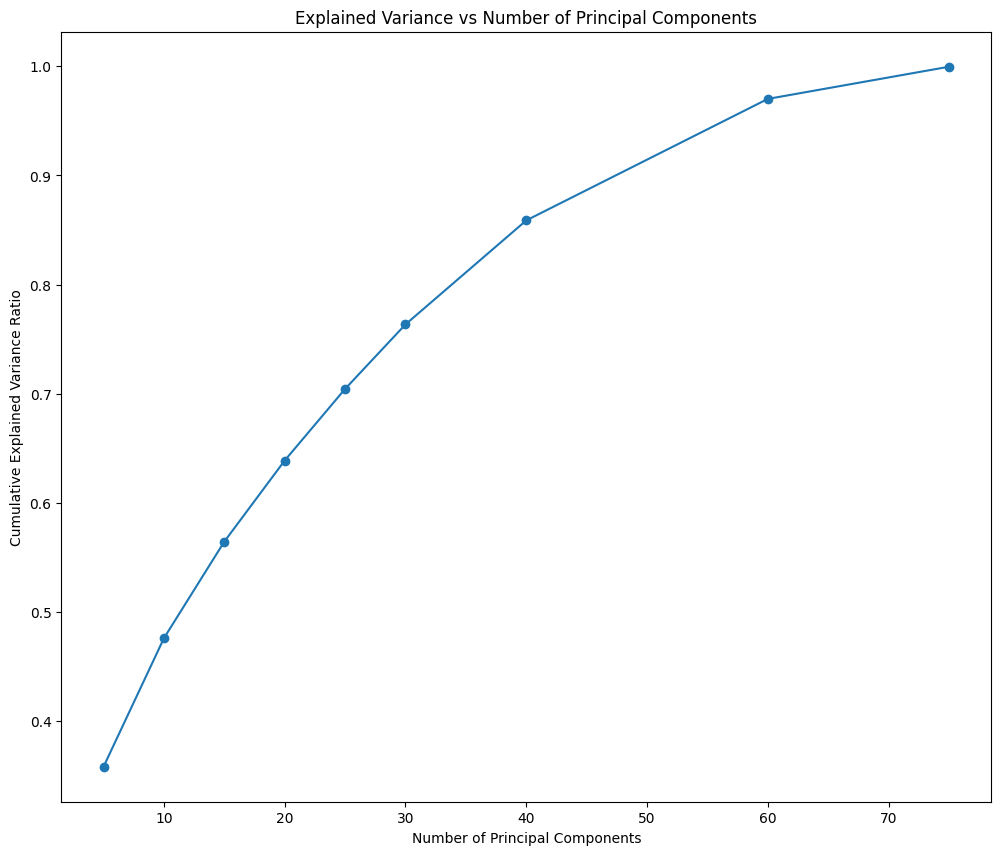

In [232]:
# '-o' specifies a line plot with circular markers at each data point
plt.plot(cs, info, '-o')
plt.title("Explained Variance vs Number of Principal Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance Ratio")
plt.show()

In [233]:
# Initialize PCA with 50 principal components
pca = PCA(n_components=50)
Xpca = pca.fit_transform(ds_scaled[:, :-1])

In [234]:
Xpca.shape

(1460, 50)

In [235]:
y = ds['SalePrice']

In [236]:
# Initialize KFold cross-validation with 5 splits
kf = KFold(n_splits=5)

# Initialize empty lists to store Mean Squared Errors (MSE) and Mean Absolute Percentage Errors (MAPE)
mses = []
mapes = []

# Counter to track the iteration (optional if you want to track which fold you're on)
n = 0

# Empty arrays to store the true values and predicted values for later evaluation
y_true, y_pred = np.array([]), np.array([])

# Perform cross-validation
for train_index, test_index in kf.split(X):
    # Split the data into training and testing sets based on the current fold
    X_train, X_test = Xpca[train_index], Xpca[test_index]  # Use PCA-transformed features
    y_train, y_test = y[train_index], y[test_index]  # Use target variable for training and testing

    # Initialize the GradientBoostingRegressor model with a fixed random state for reproducibility
    baseline_estimator = GradientBoostingRegressor(random_state=0)

    # Fit the model on the training data
    baseline_estimator.fit(X_train, y_train)

    # Append the true values (y_test) and predicted values (from model's predictions on X_test)
    # to the previously initialized arrays to collect results from all folds
    y_true = np.append(y_true, y_test)
    y_pred = np.append(y_pred, baseline_estimator.predict(X_test))

# After all folds, 'y_true' will contain all true values, and 'y_pred' will contain all predicted values
rmse = mse(y_true, y_pred)**0.5
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 35771.095737863216


Outlier Detection

In [237]:
# Initialize PCA with 2 principal components (for 2D visualization)
pca = PCA(n_components=2)

# Fit the PCA model on the scaled dataset (ds_scaled) excluding the last column (assumed to be the target)
# Then, transform the dataset into the 2D PCA space (reduce dimensionality to 2 components)
vis = pca.fit_transform(ds_scaled[:, :-1])

In [238]:
vis.shape

(1460, 2)

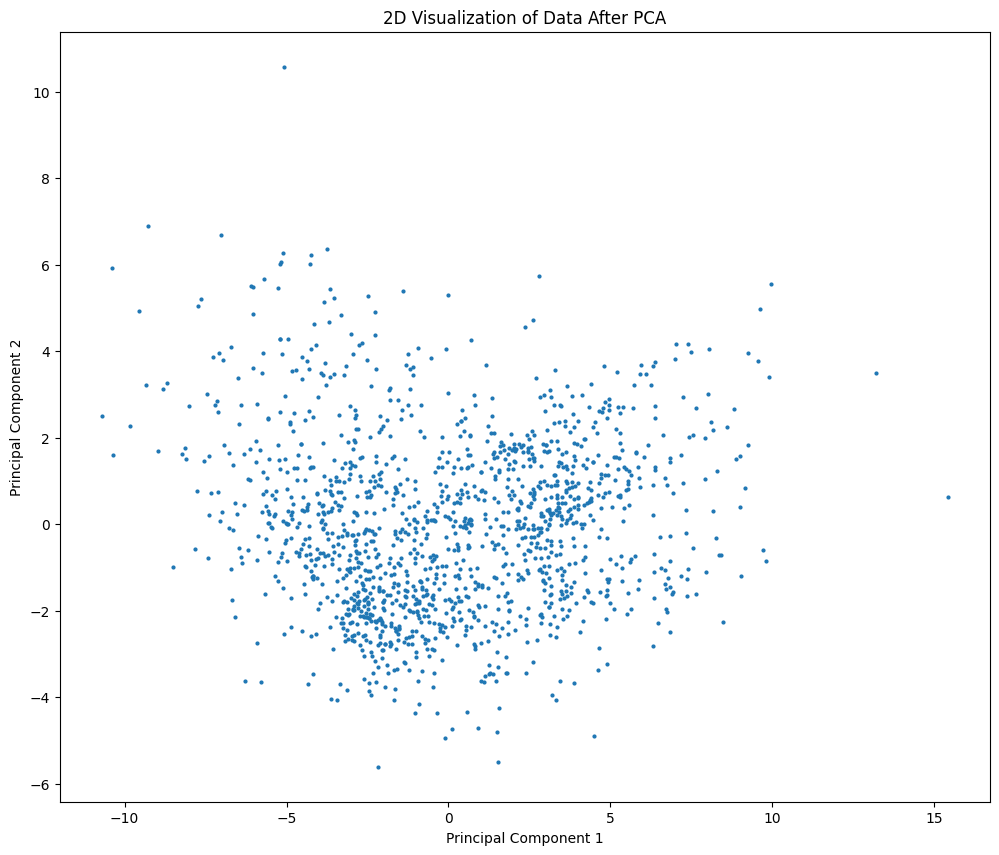

In [239]:
plt.scatter(vis[:, 0], vis[:,1], s = 4)
plt.title("2D Visualization of Data After PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

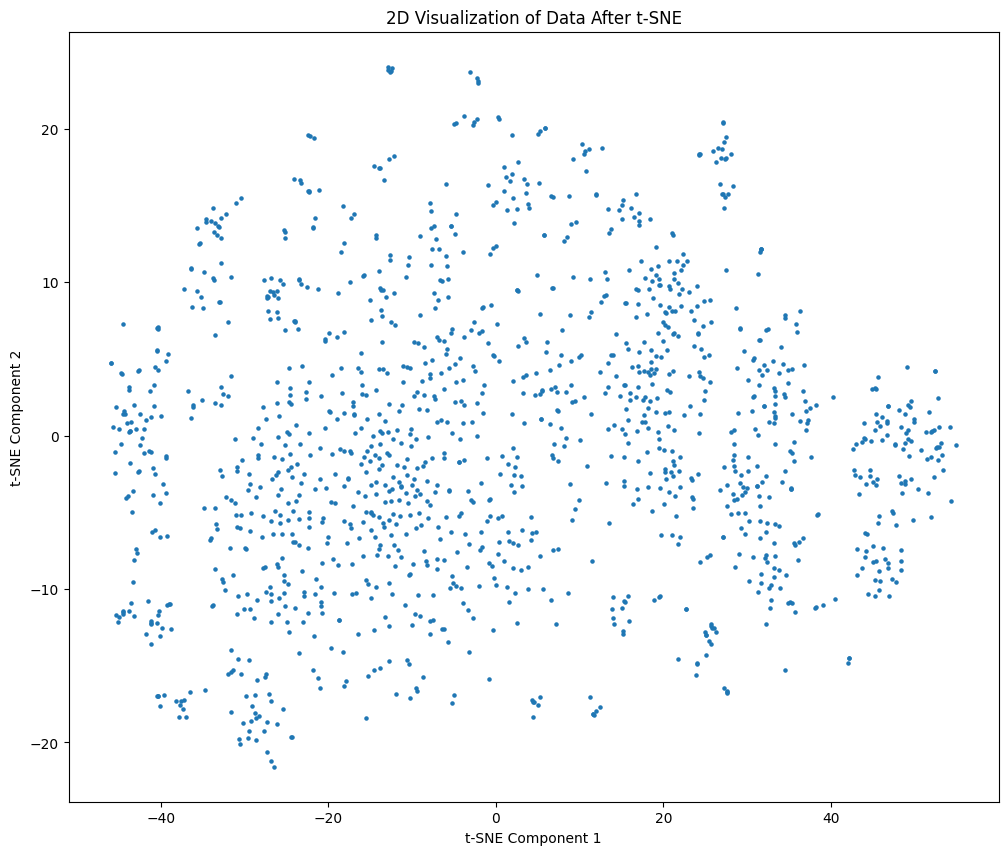

In [240]:
from sklearn.manifold import TSNE
pca = TSNE(n_components=2, perplexity=50, random_state=0)
vis = pca.fit_transform(ds_scaled[:, :-1])
plt.scatter(vis[:, 0], vis[:, 1], s=5)
plt.title("2D Visualization of Data After t-SNE")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


In [241]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
is_outlier  = IsolationForest(contamination= 0.12 , n_estimators= 1000).fit_predict(vis)
is_outlier

array([1, 1, 1, ..., 1, 1, 1])

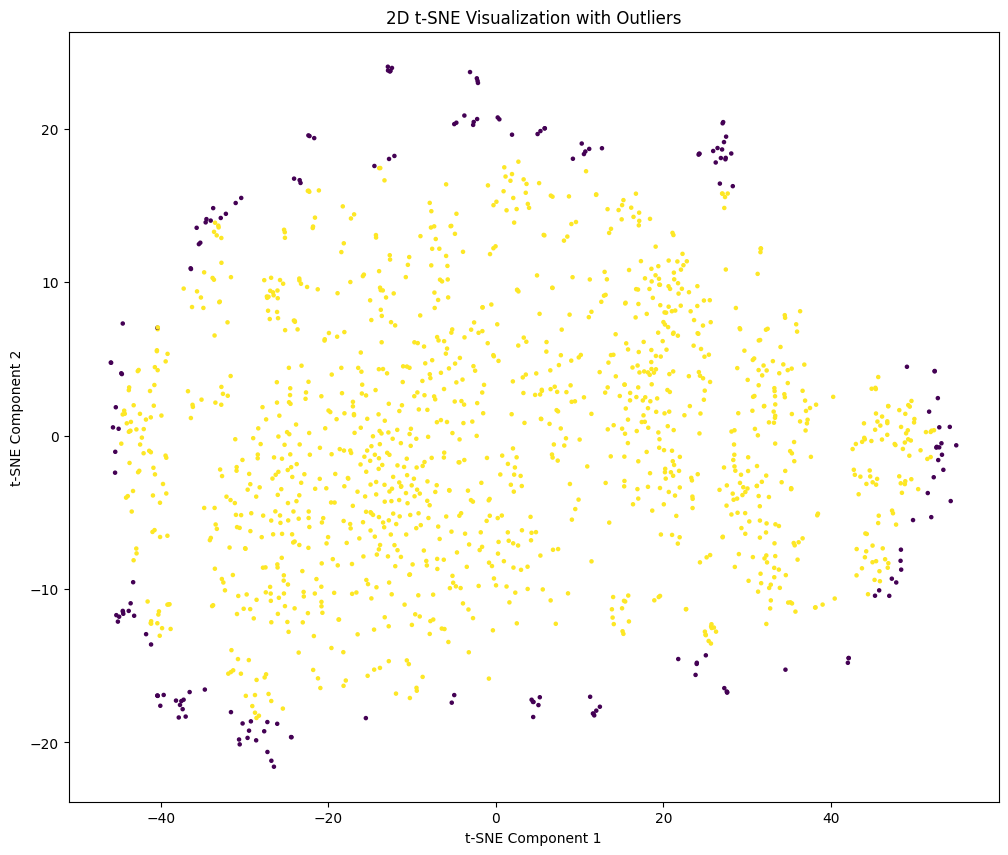

In [242]:
import matplotlib.pyplot as plt
plt.scatter(vis[:, 0], vis[:, 1], s=5, c=is_outlier)
plt.title("2D t-SNE Visualization with Outliers")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


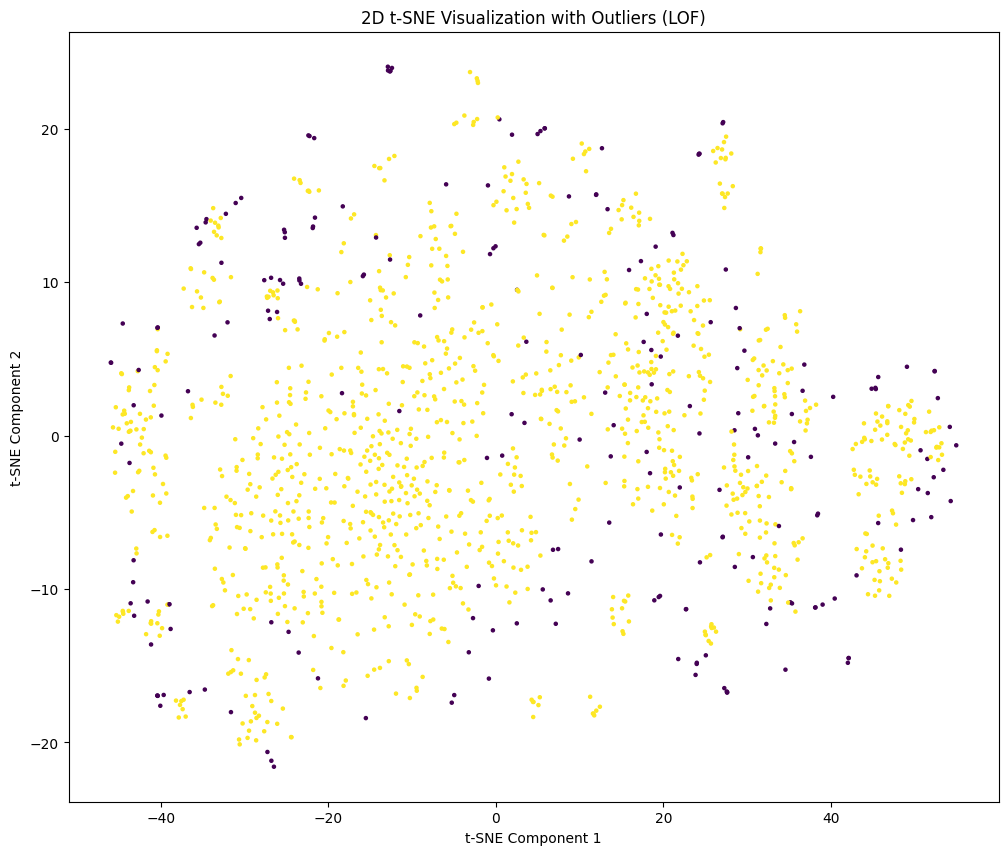

In [243]:
is_outlier = LocalOutlierFactor(contamination=0.15, n_neighbors=5).fit_predict(vis)

plt.scatter(vis[:, 0], vis[:, 1], s=5, c=is_outlier)
plt.title("2D t-SNE Visualization with Outliers (LOF)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

K Mean

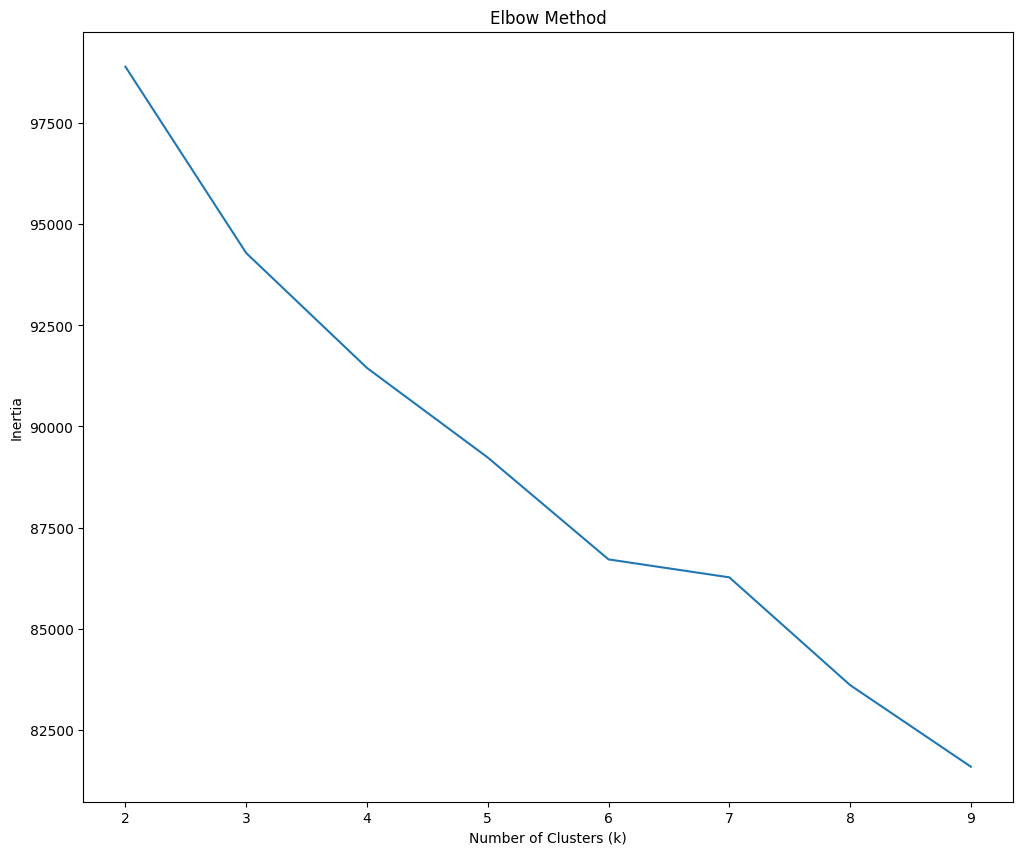

In [244]:
from sklearn.cluster import KMeans

elbow = []

for k in range(2,10):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(ds_scaled[:,:-1])
  elbow.append(kmeans.inertia_)

# At the end, the 'elbow' list contains inertia values for k=2 to k=9, which can be used to plot an elbow graph
# Plot the inertia values (elbow) for the range of k values (from 2 to 9)
plt.plot(range(2,10), elbow)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

Text(0, 0.5, 'Inertia')

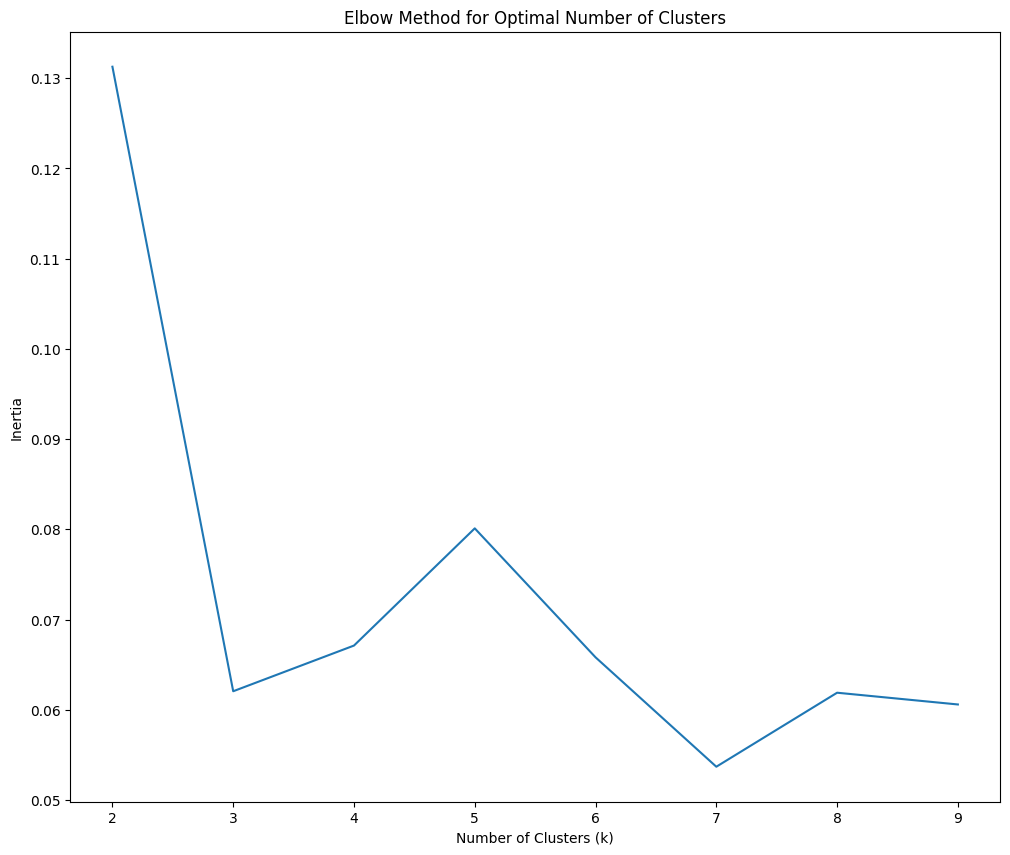

In [245]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans


elbow = []

for k in range(2,10):
  kmeans = KMeans(n_clusters = k)
  kmeans.fit(ds_scaled[:, :-1])
  elbow.append(silhouette_score(ds_scaled[:, :-1], kmeans.labels_))

plt.plot(range(2,10), elbow)
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

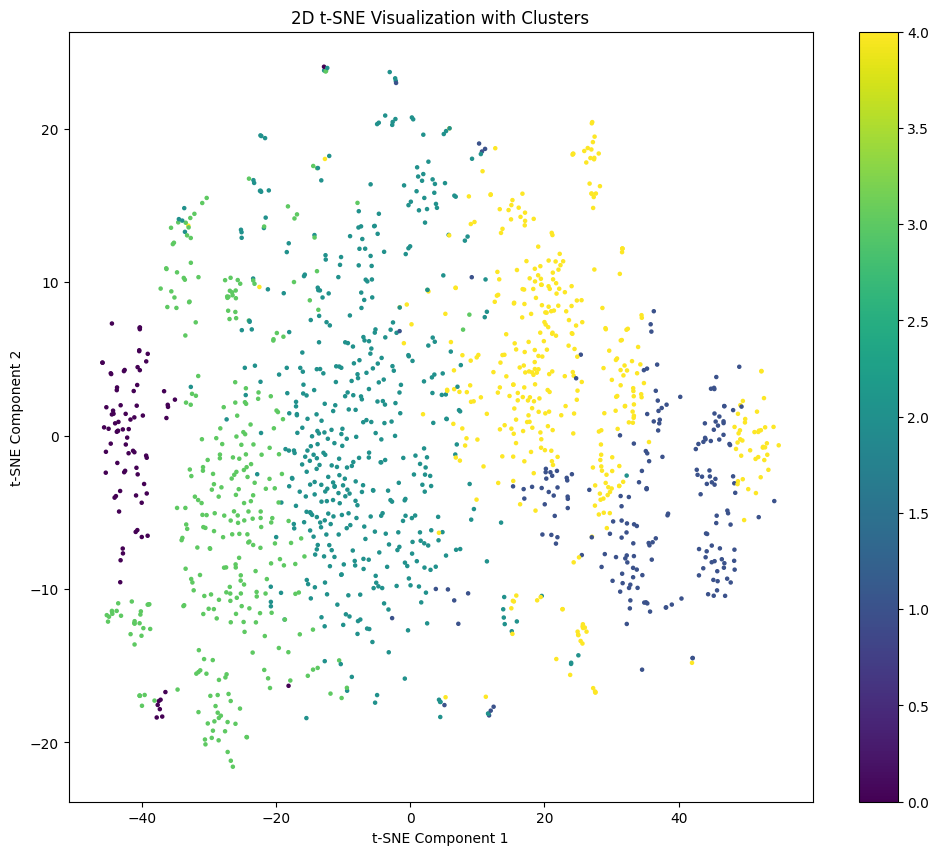

In [246]:
  kmeans = KMeans(n_clusters=5)

  kmeans.fit(ds_scaled[:, :-1])

  plt.scatter(vis[:, 0], vis[:, 1], s=5, c=kmeans.labels_)
  plt.colorbar()
  plt.title("2D t-SNE Visualization with Clusters")
  plt.xlabel("t-SNE Component 1")
  plt.ylabel("t-SNE Component 2")
  plt.show()

## Hierarchical Clustering


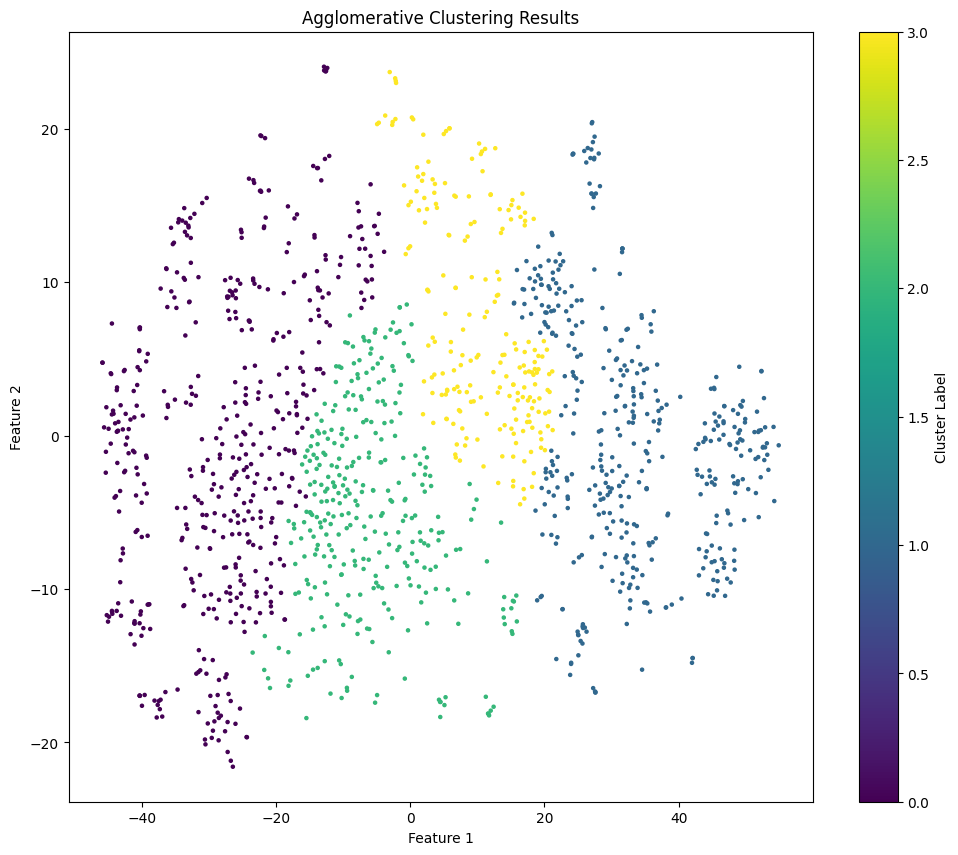

In [247]:
from sklearn.cluster import AgglomerativeClustering

hierar = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward').fit(vis)

# Scatter plot with cluster labels as colors
plt.scatter(vis[:, 0], vis[:, 1], s=5, c=hierar.labels_)
plt.colorbar(label='Cluster Label')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Agglomerative Clustering Results')
plt.show()

## DBSCAN

In [248]:
from sklearn.cluster import DBSCAN

dbsc = DBSCAN(eps = 4.5, min_samples= 45).fit(vis)
dbsc.labels_

array([ 0, -1,  0, ...,  0,  2,  2])

In [249]:
np.unique(dbsc.labels_)

array([-1,  0,  1,  2,  3,  4])

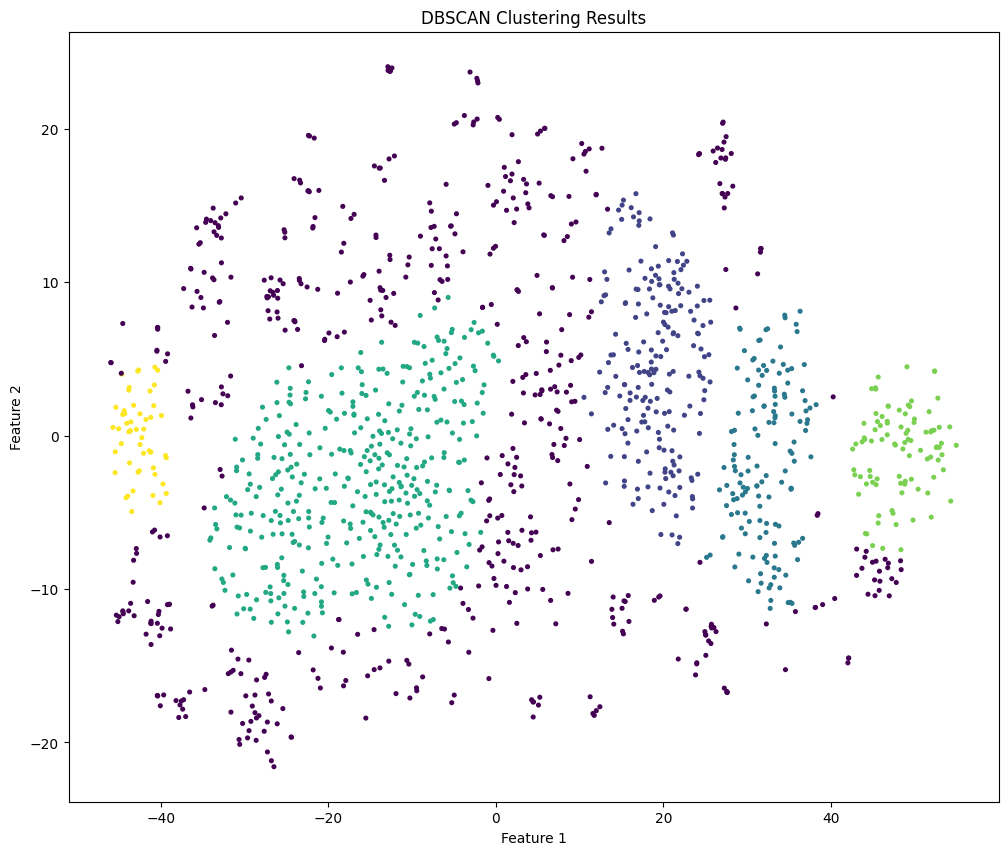

In [250]:
from sklearn.cluster import DBSCAN

dbsc = DBSCAN(eps = 4.5, min_samples= 45).fit(vis)
plt.scatter(vis[:, 0], vis[:, 1], s=7, c=dbsc.labels_)
plt.title("DBSCAN Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

EDA on Clusters

In [251]:
print("Global Mean: ", ds.SalePrice.mean())

Global Mean:  193784.76647260276


In [252]:
ds.groupby(dbsc.labels_)['SalePrice'].mean()

,SalePrice
-1,184270.901217
0,226433.120352
1,238941.562500
2,150031.788693
3,372357.129032
4,61967.647059


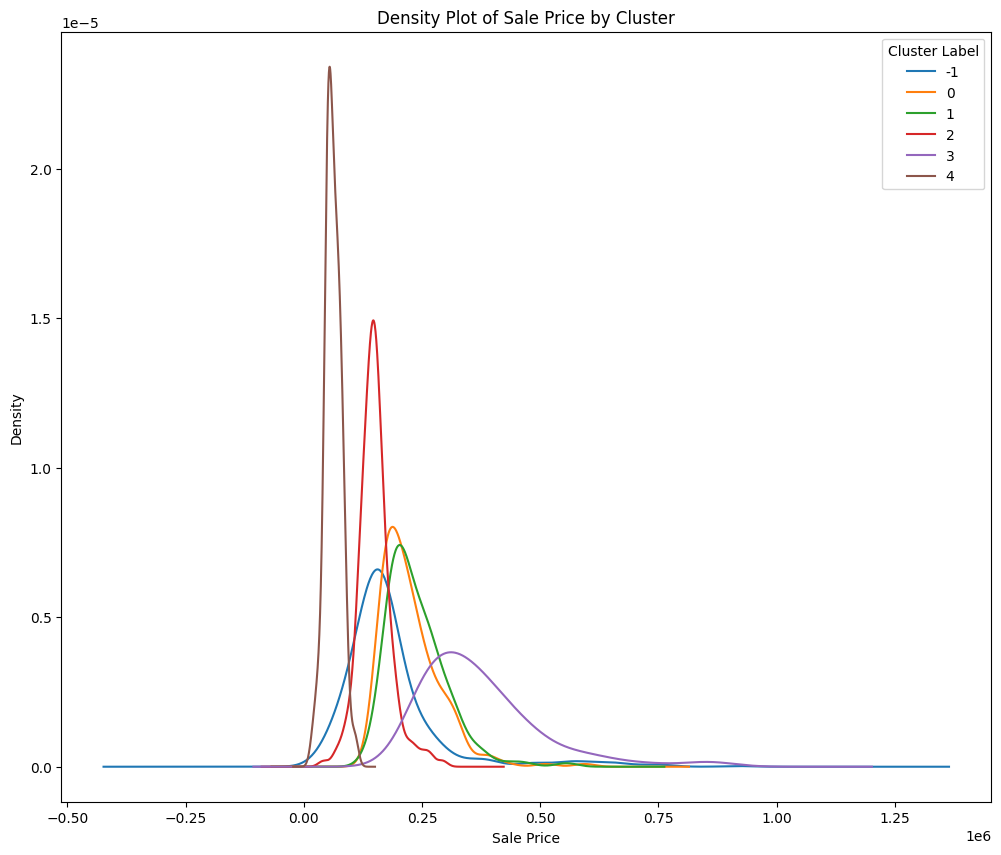

In [253]:
ds.groupby(dbsc.labels_)['SalePrice'].plot(kind = 'kde')
plt.xlabel('Sale Price')
plt.ylabel('Density')
plt.title('Density Plot of Sale Price by Cluster')
plt.legend(title="Cluster Label")
plt.show()

In [254]:
## Original X and y with outliers

X = ds_scaled[:, :-1]
y = ds['SalePrice'].values

kf = KFold(n_splits=5)

y_true, y_pred = np.array([]), np.array([])
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    baseline_estimator = GradientBoostingRegressor(random_state=0)
    baseline_estimator.fit(X_train, y_train)
    y_true = np.append(y_true, y_test)
    y_pred = np.append(y_pred, baseline_estimator.predict(X_test))
print("Mean Absolute Percentage Error (MAPE):", mape(y_true, y_pred))  # MAPE in percentage form
print("Root Mean Squared Error (RMSE):", mse(y_true, y_pred)**0.5)

Mean Absolute Percentage Error (MAPE): 0.10184115406028563
Root Mean Squared Error (RMSE): 31277.140430213938


In [259]:
fi = pd.DataFrame()

fi['feature'] = ds.columns[:-1]

fi['importance'] = baseline_estimator.feature_importances_

fi.sort_values(by = 'importance', ascending = False)

,feature,importance
11,Neighborhood,0.197634
16,OverallQual,0.168311
45,GrLivArea,0.150050
76,SaleType,0.146981
60,GarageCars,0.081378
...,...,...
47,BsmtHalfBath,0.000000
59,GarageFinish,0.000000
13,Condition2,0.000000
14,BldgType,0.000000


In [256]:
c = dbsc.labels_!=-1
X = ds_scaled[:, :-1][c] # This X does not have outliers which dbscan told me
y = ds['SalePrice'].values[c]
c = dbsc.labels_[dbsc.labels_!=-1]

kf = KFold(n_splits=5)

mses = []
mapes = []
n = 0

y_true, y_pred = np.array([]), np.array([])
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    c_train, c_test = c[train_index], c[test_index]
    baseline_estimator = GradientBoostingRegressor(random_state=0)
    baseline_estimator.fit(X_train, y_train)
    y_true = np.append(y_true, y_test)
    y_pred = np.append(y_pred, baseline_estimator.predict(X_test))

print("Mean Absolute Percentage Error (MAPE):", mape(y_true, y_pred))  # MAPE in percentage form
print("Root Mean Squared Error (RMSE):", mse(y_true, y_pred)**0.5)

Mean Absolute Percentage Error (MAPE): 0.0893061091193823
Root Mean Squared Error (RMSE): 28763.788146654668


## Evaluating Baseline model on outliers

In [258]:
outliers_X = ds_scaled[dbsc.labels_==-1][:, :-1]

outliers_y = ds[dbsc.labels_==-1]['SalePrice'].values


print("Mean Absolute Percentage Error (MAPE) for Outliers:", mape(outliers_y, baseline_estimator.predict(outliers_X)))
print("Root Mean Squared Error (RMSE) for Outliers:", mse(outliers_y, baseline_estimator.predict(outliers_X))**0.5)

Mean Absolute Percentage Error (MAPE) for Outliers: 0.1628961877701243
Root Mean Squared Error (RMSE) for Outliers: 46809.29411751332


## Target Transformation

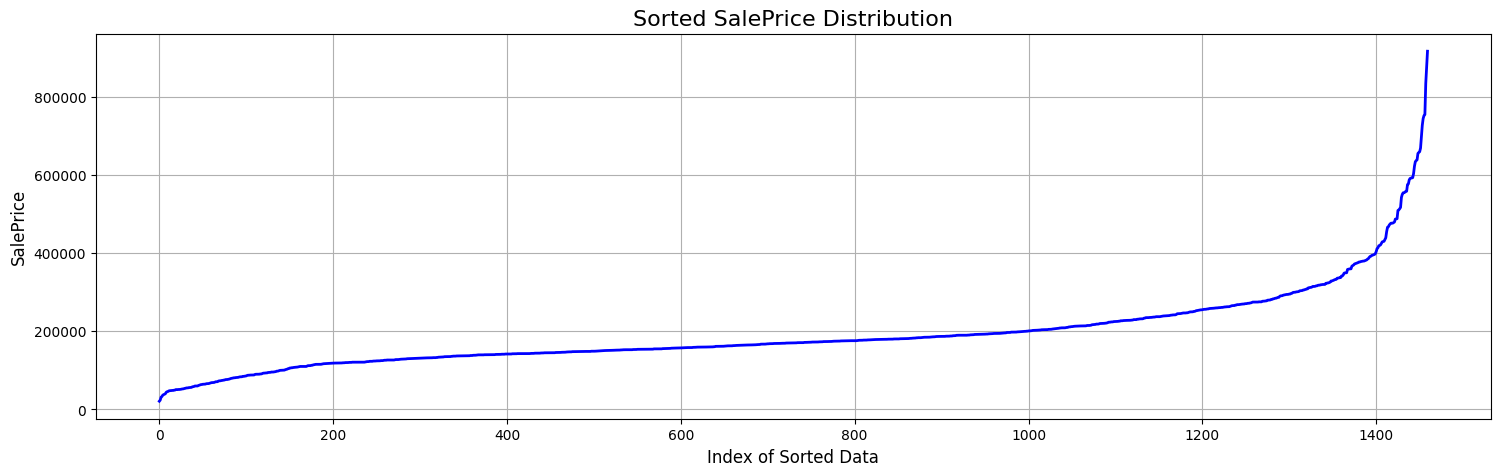

In [262]:
import matplotlib.pyplot as plt

# Create a figure with a larger size for better readability
plt.figure(figsize=(18, 5))
plt.plot(sorted(ds.SalePrice), color='b', linestyle='-', linewidth=2)
plt.title("Sorted SalePrice Distribution", fontsize=16)
plt.xlabel("Index of Sorted Data", fontsize=12)
plt.ylabel("SalePrice", fontsize=12)
plt.grid(True)
plt.show()


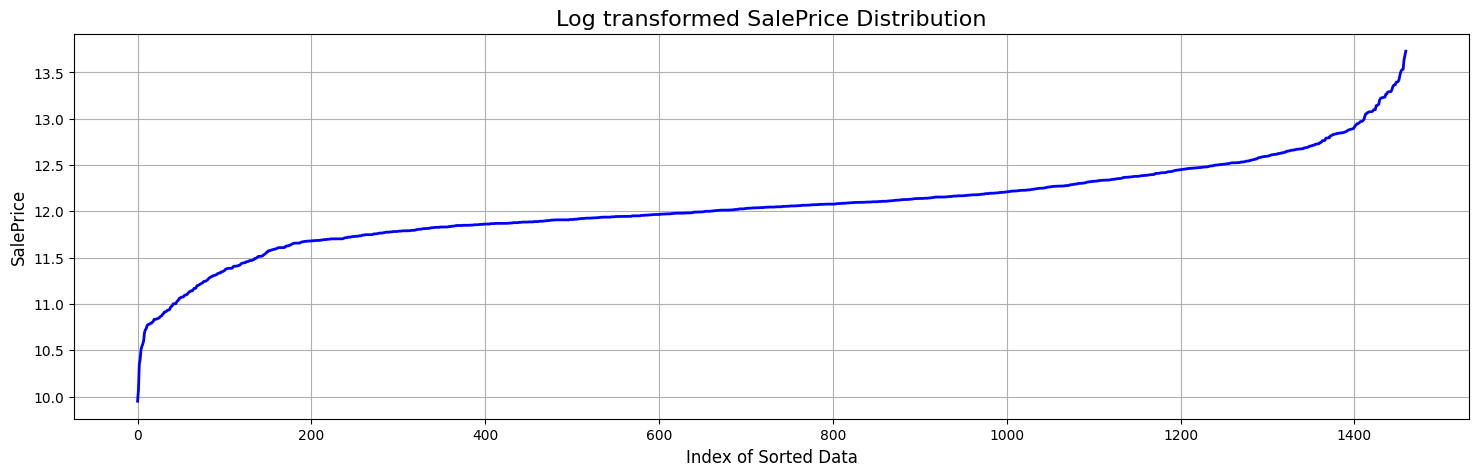

In [264]:
# Create a figure with a larger size for better readability
plt.figure(figsize=(18, 5))
plt.plot(sorted(np.log(ds.SalePrice)), color='b', linestyle='-', linewidth=2)
plt.title("Log transformed SalePrice Distribution", fontsize=16)
plt.xlabel("Index of Sorted Data", fontsize=12)
plt.ylabel("SalePrice", fontsize=12)
plt.grid(True)
plt.show()


In [266]:
c = dbsc.labels_!=-1

X = ds_scaled[:, :-1][c]


y = np.log(ds['SalePrice'].values)[c]

c = dbsc.labels_[dbsc.labels_!=-1]

kf = KFold(n_splits=5)

mses = []
mapes = []
n = 0

y_true, y_pred = np.array([]), np.array([])
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    c_train, c_test = c[train_index], c[test_index]
    baseline_estimator = GradientBoostingRegressor(random_state=0)
    baseline_estimator.fit(X_train, y_train)
    y_true = np.append(y_true, np.exp(y_test))
    y_pred = np.append(y_pred, np.exp(baseline_estimator.predict(X_test)))

print("Mean Absolute Percentage Error (MAPE):", mape(y_true, y_pred))
print("Root Mean Squared Error (RMSE):", mse(y_true, y_pred)**0.5)

Mean Absolute Percentage Error (MAPE): 0.08373568049975669
Root Mean Squared Error (RMSE): 27135.214641811104


Cluster Vise Model

In [268]:
# DBSCAN labels outliers as -1, exclude those from the dataset
c = dbsc.labels_ != -1

X = ds_scaled[:, :-1][c]  # Features excluding the target (SalePrice)
y = np.log(ds['SalePrice'].values)[c]  # Target variable log-transformed to stabilize variance

c = dbsc.labels_[dbsc.labels_ != -1]  # Cluster labels excluding outliers

kf = KFold(n_splits=5)

# Lists to store Mean Squared Error (MSE) and Mean Absolute Percentage Error (MAPE) for each cluster
mses = []
mapes = []
n = 0  # Total number of data points for calculating weighted average

for cluster in range(5):
    y_true, y_pred = np.array([]), np.array([])  # Initialize arrays to store true and predicted values

    # Perform cross-validation within each cluster
    for train_index, test_index in kf.split(X):
        # Split the data into training and testing sets based on the current fold's indices
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        c_train, c_test = c[train_index], c[test_index]

        # Initialize the Gradient Boosting Regressor model with a fixed random state for reproducibility
        estimator = GradientBoostingRegressor(random_state=0)

        # Train the model on the current fold's training data
        estimator.fit(X_train, y_train)

        # Append true values and predictions for the current fold and current cluster
        # Only consider the data points belonging to the current cluster
        y_true = np.append(y_true, np.exp(y_test[c_test == cluster]))  # Exponentiate y_test to get the original SalePrice values
        y_pred = np.append(y_pred, np.exp(estimator.predict(X_test[c_test == cluster])))  # Exponentiate predictions to get original values

    # Calculate the MSE and MAPE for the current cluster
    mses.append(mse(y_true, y_pred) * len(y_true) ** 0.5)  # Multiply by the square root of the number of points for each cluster
    mapes.append(mape(y_true, y_pred) * len(y_true))  # Multiply by the number of points in the cluster

    # Update total count of data points processed for the weighted average
    n += len(y_true)

    # Print the MSE and MAPE for the current cluster
    print(f"Cluster {cluster} - MSE: {mse(y_true, y_pred) ** 0.5:.4f}, MAPE: {mape(y_true, y_pred):.4f}")

# Calculate and print the weighted average MSE and MAPE across all clusters
# The sum of MSEs and MAPEs is divided by the total number of data points processed (n) for weighted averages
print(f"Weighted average MSE: {sum(mses) / n:.4f}")
print(f"Weighted average MAPE: {sum(mapes) / n:.4f}")

Cluster 0 - MSE: 22467.6745, MAPE: 0.0659
Cluster 1 - MSE: 24574.9509, MAPE: 0.0634
Cluster 2 - MSE: 16308.4186, MAPE: 0.0839
Cluster 3 - MSE: 61321.0615, MAPE: 0.1033
Cluster 4 - MSE: 13033.6773, MAPE: 0.1736
Weighted average MSE: 64576340.9112
Weighted average MAPE: 0.0837
